In [6]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/asifxzaman/e-commerce-behavior-dataset8000-users/ecommerce_user_behavior_8000.csv


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
import warnings
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
import seaborn as sns

# Plot styles
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12

# Pandas display
pd.set_option('display.max_columns', None)
pd.set_option('display.expand_frame_repr', False)
pd.set_option('display.precision', 2)

In [8]:
def style_df(df):
    return df.style \
        .background_gradient(cmap='coolwarm') \
        .set_properties(**{
            'border': '1px solid #ddd',
            'padding': '6px',
            'text-align': 'center'
        }) \
        .set_table_styles([
            {
                'selector': 'th',
                'props': [
                    ('background', 'linear-gradient(90deg, #4b6cb7, #182848)'),
                    ('color', 'white'),
                    ('font-weight', 'bold'),
                    ('border', '1px solid white')
                ]
            }
        ])

# Basic info

In [9]:
df = pd.read_csv('/kaggle/input/datasets/asifxzaman/e-commerce-behavior-dataset8000-users/ecommerce_user_behavior_8000.csv')

In [10]:
print(f" Dataset Shape: {df.shape}")


 Dataset Shape: (8000, 14)


In [11]:
display(style_df(df.head()))

,user_id,age,gender,device_type,time_on_site,pages_viewed,previous_purchases,cart_items,discount_seen,ad_clicked,returning_user,avg_session_time,bounce_rate,purchase
0,1.000000,56.000000,Female,Desktop,12.900000,8.000000,13.000000,1.000000,1.000000,nan,0.000000,6.970000,28.180000,1.000000
1,2.000000,46.000000,Male,Mobile,15.630000,9.000000,4.000000,6.000000,1.000000,1.000000,1.000000,19.170000,86.730000,1.000000
2,3.000000,32.000000,Female,nan,11.640000,12.000000,11.000000,0.000000,0.000000,0.000000,1.000000,8.870000,83.090000,1.000000
3,4.000000,25.000000,Female,Mobile,22.710000,5.000000,10.000000,1.000000,0.000000,0.000000,1.000000,nan,79.030000,1.000000
4,5.000000,38.000000,Female,Mobile,26.350000,9.000000,12.000000,4.000000,1.000000,0.000000,0.000000,18.150000,55.350000,1.000000


In [12]:
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Percentage (%)': missing_pct
})

missing_df = missing_df[missing_df['Missing Count'] > 0]

if len(missing_df) > 0:
    display(style_df(missing_df))
else:
    print(" No missing values")

,Missing Count,Percentage (%)
user_id,160,2.000000
age,160,2.000000
gender,160,2.000000
device_type,160,2.000000
time_on_site,160,2.000000
pages_viewed,160,2.000000
previous_purchases,160,2.000000
cart_items,160,2.000000
discount_seen,160,2.000000
ad_clicked,160,2.000000


In [13]:
display(style_df(df.describe()))

,user_id,age,time_on_site,pages_viewed,previous_purchases,cart_items,discount_seen,ad_clicked,returning_user,avg_session_time,bounce_rate,purchase
count,7840.000000,7840.000000,7840.000000,7840.000000,7840.000000,7840.000000,7840.000000,7840.000000,7840.000000,7840.000000,7840.000000,7840.000000
mean,4003.135077,38.595791,15.714673,9.970026,6.964158,4.530230,0.502551,0.502296,0.509439,15.794999,49.924402,0.998342
std,2307.898984,12.033928,8.362764,5.425485,4.281117,2.865814,0.500025,0.500027,0.499943,9.864556,29.137449,0.040689
min,1.000000,18.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.570000,0.010000,0.000000
25%,2011.750000,28.000000,8.520000,5.000000,3.000000,2.000000,0.000000,0.000000,0.000000,7.750000,24.677500,1.000000
50%,3998.000000,39.000000,15.740000,10.000000,7.000000,5.000000,1.000000,1.000000,1.000000,14.300000,49.500000,1.000000
75%,6001.250000,49.000000,22.880000,15.000000,11.000000,7.000000,1.000000,1.000000,1.000000,22.392500,75.990000,1.000000
max,8000.000000,59.000000,30.000000,19.000000,14.000000,9.000000,1.000000,1.000000,1.000000,44.750000,99.970000,1.000000


In [14]:
cat_cols = df.select_dtypes(include=['object']).columns

for col in cat_cols:
    print(f"\n {col} Distribution:")
    vc = df[col].value_counts().to_frame(name='Count')
    display(style_df(vc))




 gender Distribution:


,Count
gender,
Male,3931
Female,3909



 device_type Distribution:


,Count
device_type,
Mobile,4685
Desktop,2365
Tablet,790


In [15]:

display(style_df(pd.DataFrame(df.dtypes, columns=['Data Type'])))

,Data Type
user_id,float64
age,float64
gender,object
device_type,object
time_on_site,float64
pages_viewed,float64
previous_purchases,float64
cart_items,float64
discount_seen,float64
ad_clicked,float64


# EDA

## TARGET VARIABLE ANALYSIS

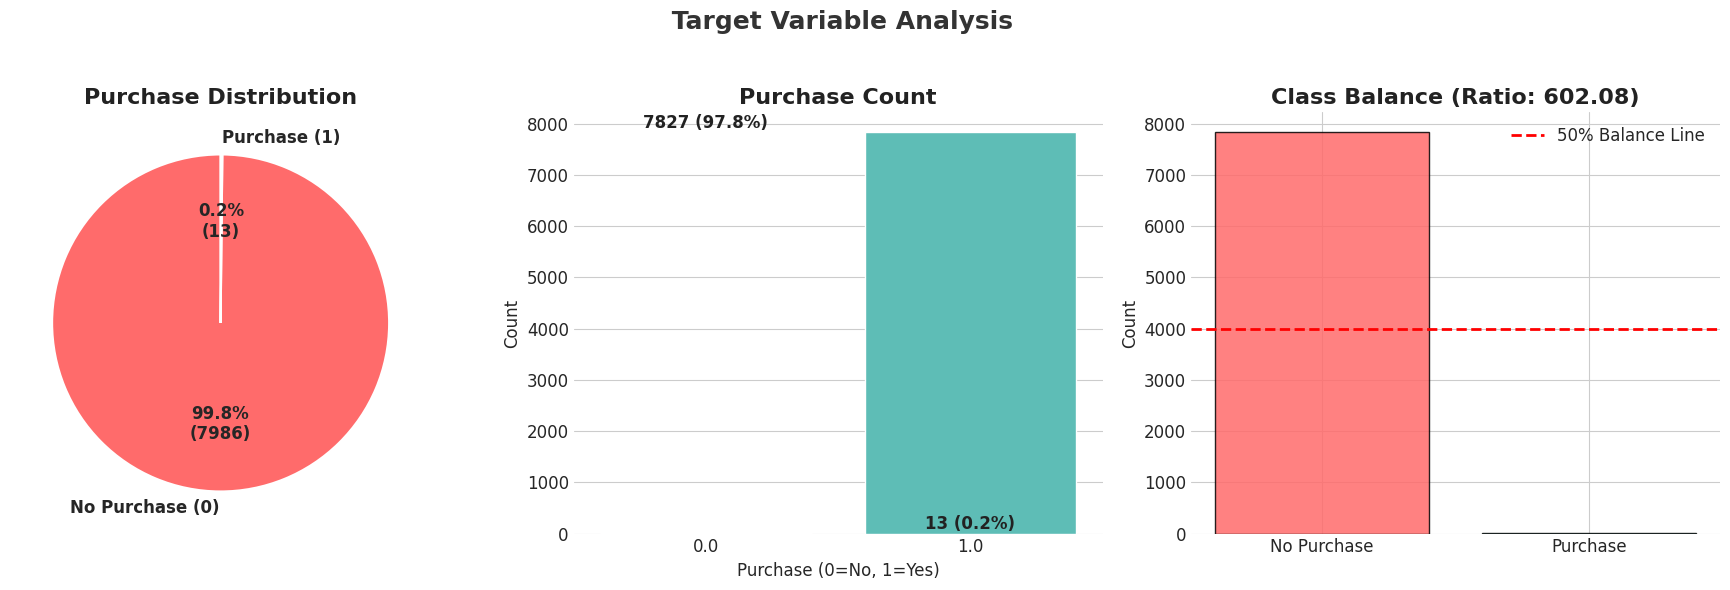


 Purchase Rate: 97.84%
 Class Imbalance Ratio: 602.08


In [16]:


# Palette
colors = ['#ff6b6b', '#4ecdc4']  
sns.set_style("whitegrid")

fig, axes = plt.subplots(1, 3, figsize=(18, 6))


# Pie Chart

purchase_counts = df['purchase'].value_counts()
axes[0].pie(
    purchase_counts.values, 
    labels=['No Purchase (0)', 'Purchase (1)'], 
    autopct=lambda p: f'{p:.1f}%\n({int(p/100*len(df))})', 
    startangle=90, 
    colors=colors,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5},
    textprops={'fontsize': 12, 'fontweight': 'bold'}
)
axes[0].set_title('Purchase Distribution', fontsize=16, fontweight='bold', color='#222')


#  Countplot

sns.countplot(data=df, x='purchase', ax=axes[1], palette=colors)
axes[1].set_title('Purchase Count', fontsize=16, fontweight='bold', color='#222')
axes[1].set_xlabel('Purchase (0=No, 1=Yes)', fontsize=12)
axes[1].set_ylabel('Count', fontsize=12)

# Annotate bars
for i, v in enumerate(purchase_counts.values):
    axes[1].text(i, v + len(df)*0.01, f"{v} ({v/len(df)*100:.1f}%)", 
                 ha='center', fontweight='bold', color='#222', fontsize=12)


#  Class Balance

axes[2].bar(['No Purchase', 'Purchase'], purchase_counts.values, color=colors, alpha=0.85, edgecolor='black')
axes[2].axhline(y=len(df)/2, color='red', linestyle='--', linewidth=2, label='50% Balance Line')
axes[2].set_title(f'Class Balance (Ratio: {purchase_counts[1]/purchase_counts[0]:.2f})', fontsize=16, fontweight='bold', color='#222')
axes[2].set_ylabel('Count', fontsize=12)
axes[2].legend()

# Layout

plt.suptitle(' Target Variable Analysis', fontsize=18, fontweight='bold', color='#333')
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

# Numeric summary

purchase_rate = purchase_counts[1]/len(df)*100
balance_ratio = purchase_counts[1] / purchase_counts[0] if purchase_counts[0] > 0 else 0
print(f"\n Purchase Rate: {purchase_rate:.2f}%")
print(f" Class Imbalance Ratio: {balance_ratio:.2f}")

## DEMOGRAPHIC ANALYSIS

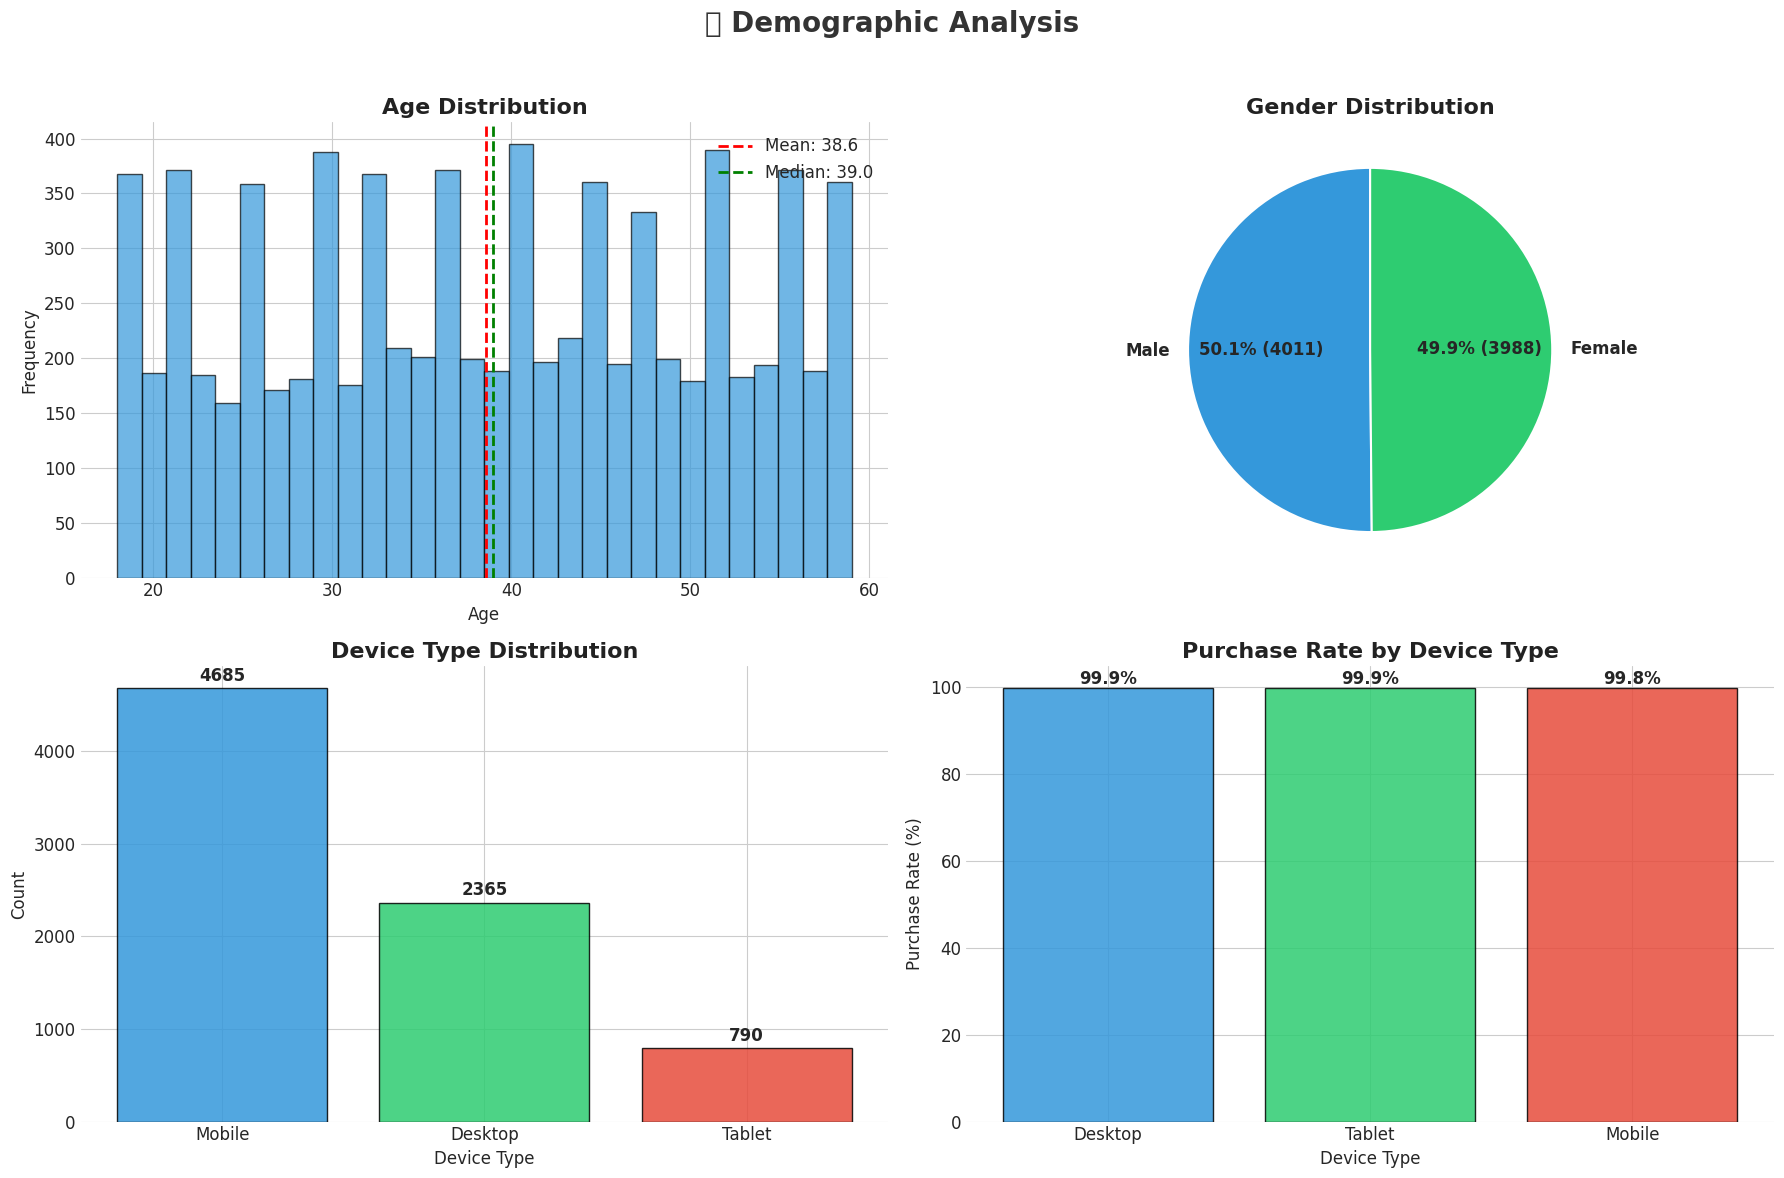


 Purchase Rate by Age Group:


age_group
18-25    99.9%
46-55    99.9%
56-60    99.9%
36-45    99.8%
26-35    99.7%
Name: purchase, dtype: object

In [17]:

sns.set_style("whitegrid")
colors = ['#3498db', '#2ecc71', '#e74c3c', '#ff6b6b', '#4ecdc4']

fig, axes = plt.subplots(2, 2, figsize=(18, 12))


#  Age Distribution

age_data = df['age'].dropna()
axes[0,0].hist(age_data, bins=30, edgecolor='black', alpha=0.7, color='#3498db')
axes[0,0].axvline(age_data.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {age_data.mean():.1f}')
axes[0,0].axvline(age_data.median(), color='green', linestyle='--', linewidth=2, label=f'Median: {age_data.median():.1f}')
axes[0,0].set_title('Age Distribution', fontsize=16, fontweight='bold', color='#222')
axes[0,0].set_xlabel('Age', fontsize=12)
axes[0,0].set_ylabel('Frequency', fontsize=12)
axes[0,0].legend()


# Gender Distribution

gender_counts = df['gender'].value_counts()
axes[0,1].pie(
    gender_counts.values, 
    labels=gender_counts.index, 
    autopct=lambda p: f'{p:.1f}% ({int(p/100*len(df))})',
    startangle=90, 
    colors=colors[:len(gender_counts)],
    wedgeprops={'edgecolor':'white','linewidth':1.5},
    textprops={'fontsize':12,'fontweight':'bold'}
)
axes[0,1].set_title('Gender Distribution', fontsize=16, fontweight='bold', color='#222')


# Device Type Distribution

device_counts = df['device_type'].value_counts()
axes[1,0].bar(device_counts.index, device_counts.values, color=colors[:len(device_counts)], alpha=0.85, edgecolor='black')
axes[1,0].set_title('Device Type Distribution', fontsize=16, fontweight='bold', color='#222')
axes[1,0].set_xlabel('Device Type', fontsize=12)
axes[1,0].set_ylabel('Count', fontsize=12)

# Add count labels
for i, v in enumerate(device_counts.values):
    axes[1,0].text(i, v + len(df)*0.01, str(v), ha='center', fontweight='bold', fontsize=12)


#  Purchase Rate by Device

device_purchase = df.groupby('device_type')['purchase'].mean().sort_values(ascending=False)
axes[1,1].bar(device_purchase.index, device_purchase.values*100, color=colors[:len(device_purchase)], alpha=0.85, edgecolor='black')
axes[1,1].set_title('Purchase Rate by Device Type', fontsize=16, fontweight='bold', color='#222')
axes[1,1].set_xlabel('Device Type', fontsize=12)
axes[1,1].set_ylabel('Purchase Rate (%)', fontsize=12)

# Annotate percentages
for i, v in enumerate(device_purchase.values):
    axes[1,1].text(i, v*100 + 1, f'{v*100:.1f}%', ha='center', fontweight='bold', fontsize=12)

plt.suptitle('👤 Demographic Analysis', fontsize=20, fontweight='bold', color='#333')
plt.tight_layout(rect=[0,0,1,0.96])
plt.show()


# Purchase Rate by Age Group

df['age_group'] = pd.cut(df['age'], bins=[18, 25, 35, 45, 55, 60], 
                          labels=['18-25', '26-35', '36-45', '46-55', '56-60'])
age_purchase = df.groupby('age_group')['purchase'].mean().sort_values(ascending=False)

print("\n Purchase Rate by Age Group:")
display(age_purchase.apply(lambda x: f"{x*100:.1f}%"))

## BEHAVIORAL METRICS ANALYSIS

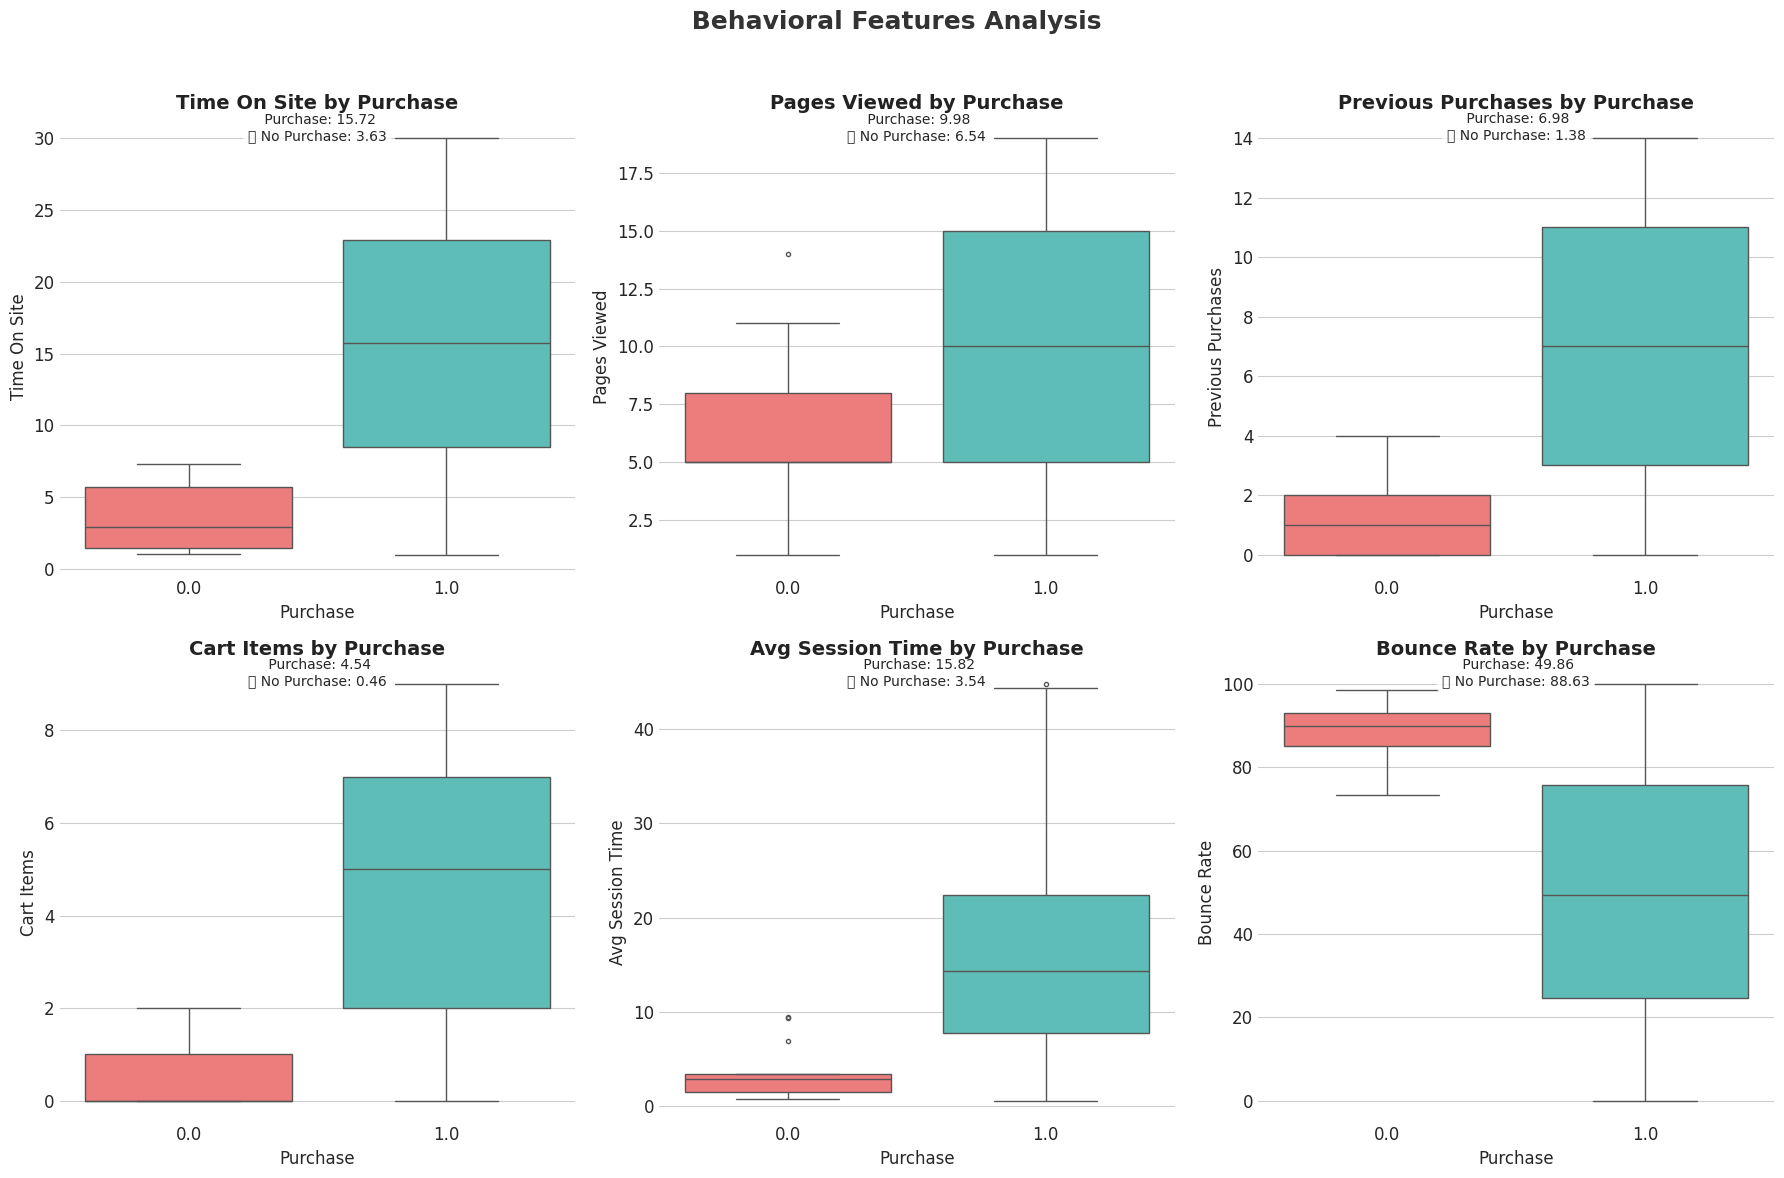

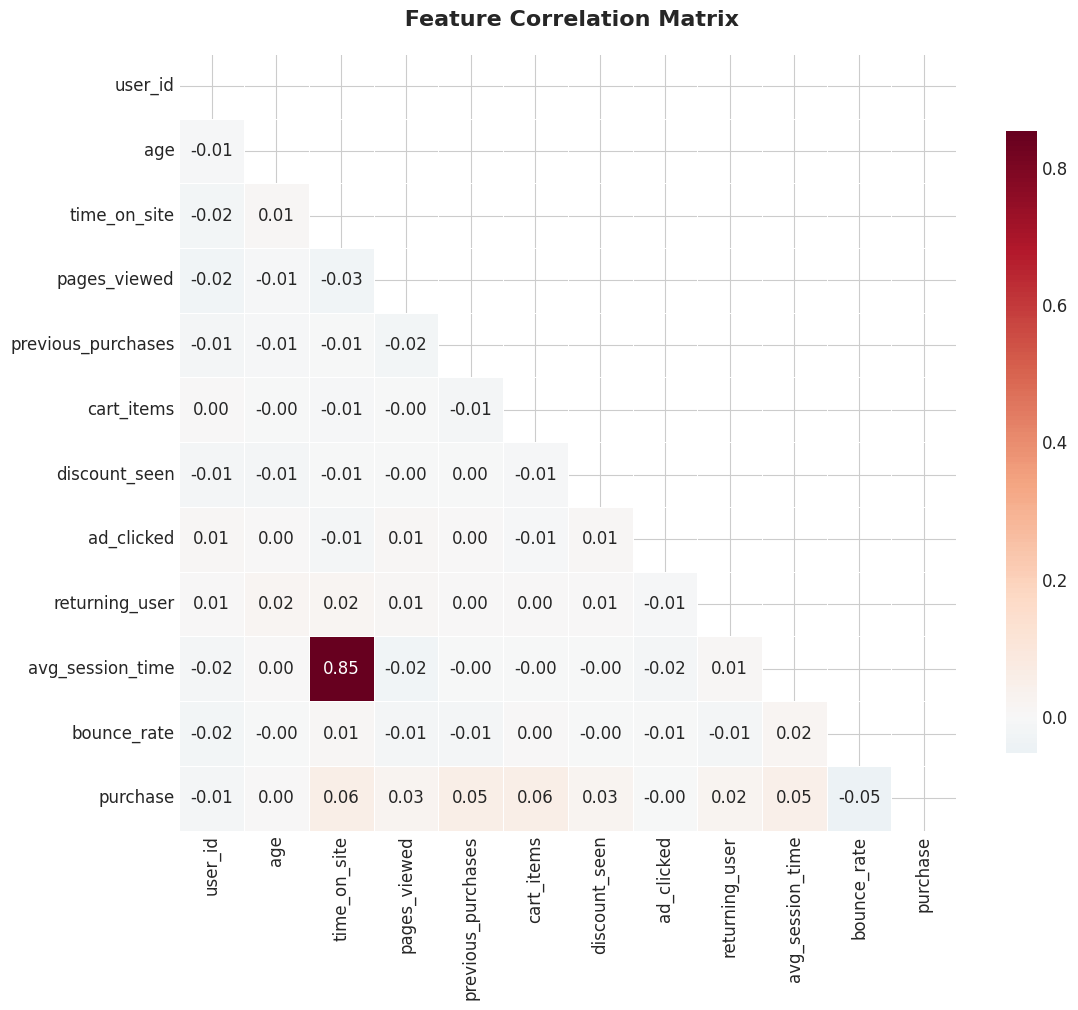


 Top Correlations with Purchase:


purchase               1.00
cart_items             0.06
time_on_site           0.06
previous_purchases     0.05
avg_session_time       0.05
discount_seen          0.03
pages_viewed           0.03
returning_user         0.02
age                    0.00
ad_clicked            -0.00
user_id               -0.01
bounce_rate           -0.05
Name: purchase, dtype: object

In [18]:

from IPython.display import display

sns.set_style("whitegrid")
box_colors = ['#ff6b6b', '#4ecdc4']


# Behavioral Analysis

behavioral_cols = ['time_on_site', 'pages_viewed', 'previous_purchases', 
                   'cart_items', 'avg_session_time', 'bounce_rate']

fig, axes = plt.subplots(2, 3, figsize=(18, 12))

for idx, col in enumerate(behavioral_cols):
    row = idx // 3
    col_idx = idx % 3
    
    sns.boxplot(x='purchase', y=col, data=df, ax=axes[row, col_idx], palette=box_colors, fliersize=3)
    axes[row, col_idx].set_title(f'{col.replace("_", " ").title()} by Purchase', fontsize=14, fontweight='bold', color='#222')
    axes[row, col_idx].set_xlabel('Purchase', fontsize=12)
    axes[row, col_idx].set_ylabel(col.replace("_", " ").title(), fontsize=12)
    
    # Add mean statistics
    mean_purchase = df[df['purchase'] == 1][col].mean()
    mean_no_purchase = df[df['purchase'] == 0][col].mean()
    axes[row, col_idx].text(0.5, axes[row, col_idx].get_ylim()[1]*0.95, 
                            f' Purchase: {mean_purchase:.2f}\n❌ No Purchase: {mean_no_purchase:.2f}',
                            ha='center', fontsize=10, bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))

plt.suptitle(' Behavioral Features Analysis', fontsize=18, fontweight='bold', color='#333')
plt.tight_layout(rect=[0,0,1,0.96])
plt.show()


#  Correlation Heatmap

plt.figure(figsize=(12,10))
numeric_cols = df.select_dtypes(include=[np.number]).columns
correlation_matrix = df[numeric_cols].corr()

# Mask upper triangle
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))

sns.heatmap(
    correlation_matrix, 
    mask=mask, 
    annot=True, 
    fmt='.2f', 
    cmap='RdBu_r', 
    center=0, 
    square=True, 
    linewidths=0.5, 
    cbar_kws={"shrink": 0.8}
)
plt.title(' Feature Correlation Matrix', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()


#  Top correlations with purchase

corr_with_purchase = correlation_matrix['purchase'].sort_values(ascending=False)
print("\n Top Correlations with Purchase:")
display(corr_with_purchase.apply(lambda x: f"{x:.2f}"))

## MARKETING EFFECTIVENESS ANALYSIS

KeyError: 'marketing_category'

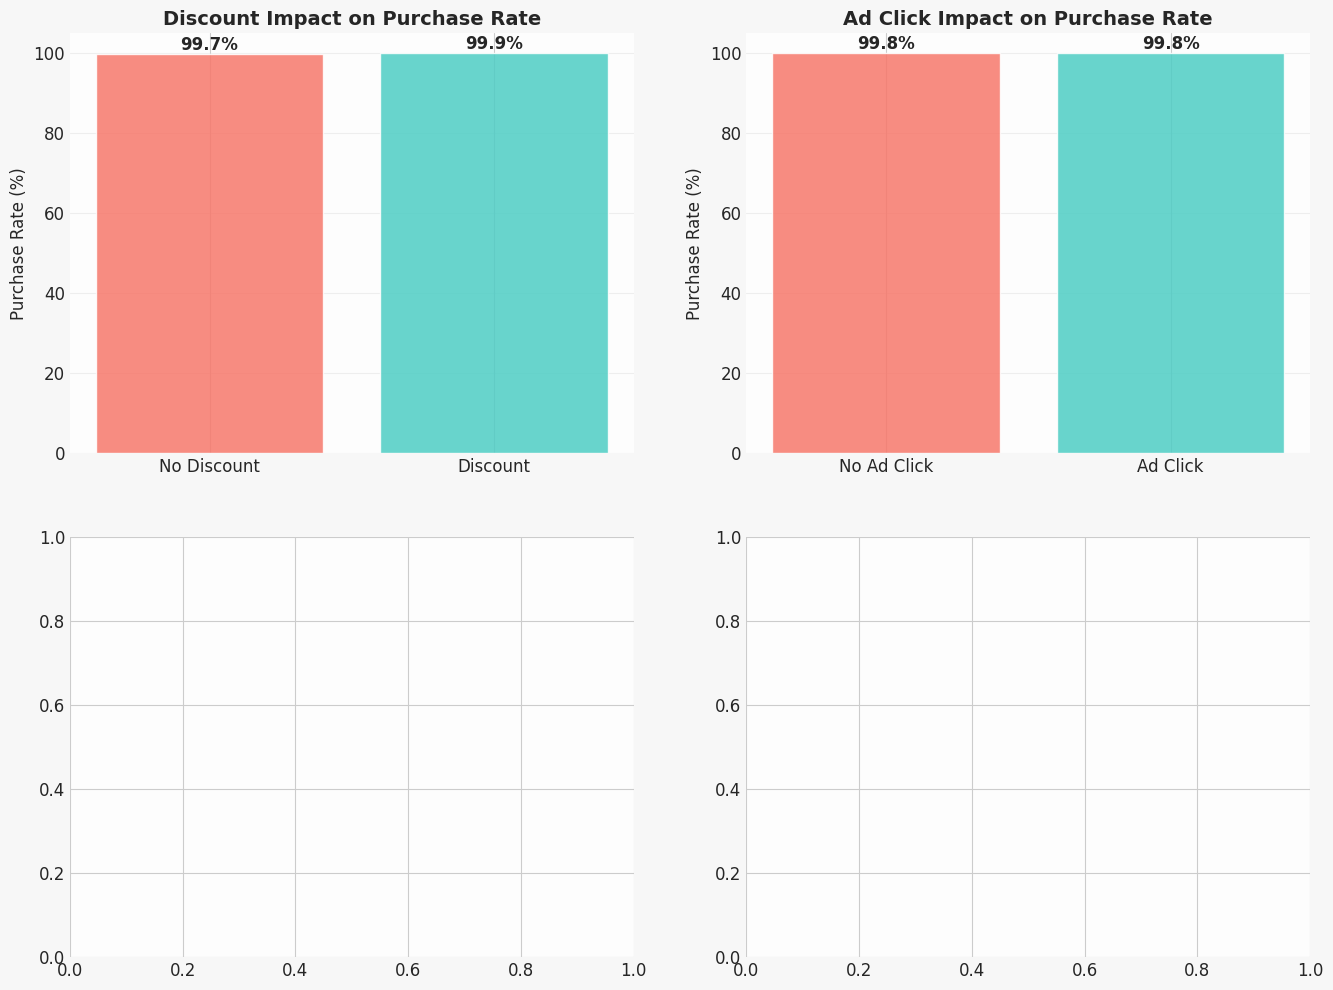

In [19]:


sns.set_style("whitegrid")
plt.rcParams['figure.facecolor'] = '#f7f7f7' 
plt.rcParams['axes.facecolor'] = '#fdfdfd'
plt.rcParams['axes.edgecolor'] = '#ddd'


# Marketing Impact Plots

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

#  Discount Impact
discount_purchase = df.groupby('discount_seen')['purchase'].agg(['mean', 'count'])
colors_discount = ['#f7786b', '#4ecdc4']
axes[0,0].bar(['No Discount', 'Discount'], discount_purchase['mean']*100, color=colors_discount, alpha=0.85)
axes[0,0].set_title('Discount Impact on Purchase Rate', fontsize=14, fontweight='bold')
axes[0,0].set_ylabel('Purchase Rate (%)')
for i, v in enumerate(discount_purchase['mean']):
    axes[0,0].text(i, v*100 + 1, f'{v*100:.1f}%', ha='center', fontweight='bold')
axes[0,0].set_ylim(0, max(discount_purchase['mean']*100) + 5)
axes[0,0].grid(axis='y', alpha=0.3)

#  Ad Click Impact
ad_purchase = df.groupby('ad_clicked')['purchase'].agg(['mean', 'count'])
colors_ad = ['#f7786b', '#4ecdc4']
axes[0,1].bar(['No Ad Click', 'Ad Click'], ad_purchase['mean']*100, color=colors_ad, alpha=0.85)
axes[0,1].set_title('Ad Click Impact on Purchase Rate', fontsize=14, fontweight='bold')
axes[0,1].set_ylabel('Purchase Rate (%)')
for i, v in enumerate(ad_purchase['mean']):
    axes[0,1].text(i, v*100 + 1, f'{v*100:.1f}%', ha='center', fontweight='bold')
axes[0,1].set_ylim(0, max(ad_purchase['mean']*100) + 5)
axes[0,1].grid(axis='y', alpha=0.3)

# Combined Marketing Impact
ordered_categories = ['No Marketing', 'Discount Only', 'Ad Only', 'Both']
marketing_impact_ordered = df.groupby('marketing_category')['purchase'].mean().reindex(ordered_categories).fillna(0)
colors_combo = ['#95a5a6', '#3498db', '#e74c3c', '#2ecc71']
axes[1,0].bar(ordered_categories, marketing_impact_ordered.values*100, color=colors_combo, alpha=0.85)
axes[1,0].set_title('Combined Marketing Impact', fontsize=14, fontweight='bold')
axes[1,0].set_ylabel('Purchase Rate (%)')
for i, v in enumerate(marketing_impact_ordered.values):
    axes[1,0].text(i, v*100 + 1, f'{v*100:.1f}%', ha='center', fontweight='bold')
axes[1,0].set_ylim(0, max(marketing_impact_ordered.values*100) + 5)
axes[1,0].grid(axis='y', alpha=0.3)

#  Purchase Funnel
funnel_data = {
    'Visitors': len(df),
    'Pages Viewed > 5': len(df[df['pages_viewed']>5]),
    'Added to Cart': len(df[df['cart_items']>0]),
    'Made Purchase': len(df[df['purchase']==1])
}
funnel_df = pd.DataFrame(list(funnel_data.items()), columns=['Stage','Count'])
axes[1,1].barh(funnel_df['Stage'], funnel_df['Count'], color=plt.cm.viridis(np.linspace(0.3,0.9,len(funnel_df))), alpha=0.9)
axes[1,1].set_title('Purchase Funnel', fontsize=14, fontweight='bold')
axes[1,1].set_xlabel('Number of Users')
for i, v in enumerate(funnel_df['Count']):
    axes[1,1].text(v + 50, i, f'{v:,}', va='center', fontweight='bold')
axes[1,1].invert_yaxis()  # Funnel top-down
axes[1,1].grid(axis='x', alpha=0.3)

plt.suptitle(' Marketing Effectiveness Analysis', fontsize=18, fontweight='bold', color='#333')
plt.tight_layout(rect=[0,0,1,0.96])
plt.show()


# Marketing Interaction Heatmap

plt.figure(figsize=(8,6))
marketing_matrix = pd.crosstab(df['discount_seen'].fillna(0), df['ad_clicked'].fillna(0), values=df['purchase'], aggfunc='mean')
sns.heatmap(marketing_matrix*100, annot=True, fmt='.1f', cmap='YlGnBu', center=50, square=True, linewidths=1, cbar_kws={'label':'Purchase Rate (%)'})
plt.title('Marketing Interaction Heatmap', fontsize=14, fontweight='bold')
plt.xlabel('Ad Clicked')
plt.ylabel('Discount Seen')
plt.xticks([0.5, 1.5], ['No', 'Yes'])
plt.yticks([0.5, 1.5], ['No', 'Yes'])
plt.tight_layout()
plt.show()

## BEHAVIORAL PATTERNS

In [ ]:

sns.set_style("whitegrid")
plt.rcParams['figure.facecolor'] = '#f7f7f7'  
plt.rcParams['axes.facecolor'] = '#fcfcfc'
plt.rcParams['axes.edgecolor'] = '#ddd'

fig, axes = plt.subplots(2, 2, figsize=(16, 12))


# Cart Items vs Pages Viewed

scatter = axes[0,0].scatter(
    df['pages_viewed'], df['cart_items'], 
    c=df['purchase'], cmap='RdYlGn', alpha=0.7, s=70, edgecolors='w', linewidth=0.5
)
axes[0,0].set_xlabel('Pages Viewed', fontsize=12)
axes[0,0].set_ylabel('Cart Items', fontsize=12)
axes[0,0].set_title('Purchase Behavior: Cart Items vs Pages Viewed', fontsize=14, fontweight='bold')
cbar = plt.colorbar(scatter, ax=axes[0,0])
cbar.set_label('Purchase (0=No, 1=Yes)', rotation=270, labelpad=15)


#  Time on Site by Device & Purchase

sns.boxplot(
    x='device_type', y='time_on_site', hue='purchase', data=df, 
    ax=axes[0,1], palette=['#ff6b6b','#4ecdc4']
)
axes[0,1].set_title('Time on Site by Device & Purchase', fontsize=14, fontweight='bold')
axes[0,1].set_xlabel('Device Type')
axes[0,1].set_ylabel('Time on Site (minutes)')
axes[0,1].legend(title='Purchase', labels=['No', 'Yes'], loc='upper right')


# Returning Users vs Purchase Rate

returning_purchase = df.groupby('returning_user')['purchase'].mean()
bars = axes[1,0].bar(
    ['New User', 'Returning User'], returning_purchase.values*100,
    color=['#3498db', '#2ecc71'], alpha=0.85
)
axes[1,0].set_title('Returning Users vs Purchase Rate', fontsize=14, fontweight='bold')
axes[1,0].set_ylabel('Purchase Rate (%)')
axes[1,0].set_ylim(0, max(returning_purchase.values*100)+10)
axes[1,0].grid(axis='y', alpha=0.3)

# Add annotations on bars
for bar in bars:
    height = bar.get_height()
    axes[1,0].text(bar.get_x() + bar.get_width()/2, height + 1, f'{height:.1f}%', ha='center', fontweight='bold')


#  Bounce Rate Distribution by Purchase

sns.kdeplot(
    data=df, x='bounce_rate', hue='purchase', fill=True, alpha=0.5, 
    ax=axes[1,1], palette=['#ff6b6b','#4ecdc4']
)
axes[1,1].set_title('Bounce Rate Distribution by Purchase', fontsize=14, fontweight='bold')
axes[1,1].set_xlabel('Bounce Rate')
axes[1,1].set_ylabel('Density')
axes[1,1].legend(title='Purchase', labels=['No', 'Yes'], loc='upper right')

plt.suptitle(' User Behavioral Analysis', fontsize=18, fontweight='bold', color='#333')
plt.tight_layout(rect=[0,0,1,0.96])
plt.show()


# Engagement Segments

df['engagement_score'] = (
    df['pages_viewed'] / df['pages_viewed'].max() + 
    df['time_on_site'] / df['time_on_site'].max()
) / 2

df['segment'] = pd.cut(
    df['engagement_score'], bins=[0, 0.33, 0.67, 1], 
    labels=['Low Engagement', 'Medium Engagement', 'High Engagement']
)

segment_purchase = df.groupby('segment')['purchase'].mean()
print("\n Purchase Rate by Engagement Segment:")
for seg, rate in segment_purchase.items():
    print(f"{seg}: {rate*100:.1f}%")

In [ ]:

insights = {
    'Overall Conversion Rate': f"{df['purchase'].mean()*100:.2f}%",
    'Highest Converting Device': f"{device_purchase.idxmax()} ({device_purchase.max()*100:.1f}%)",
    'Best Age Group': f"{age_purchase.idxmax()} ({age_purchase.max()*100:.1f}%)",
    'Discount Impact': f"{(discount_purchase.loc[1, 'mean'] - discount_purchase.loc[0, 'mean'])*100:+.1f}%",
    'Ad Click Impact': f"{(ad_purchase.loc[1, 'mean'] - ad_purchase.loc[0, 'mean'])*100:+.1f}%",
    'Returning User Impact': f"{(returning_purchase.loc[1] - returning_purchase.loc[0])*100:+.1f}%"
}

In [ ]:
import re
import numpy as np

# Function to extract numeric value from string
def extract_numeric(val):
    match = re.search(r"[\d\.]+", str(val))  # find first number (int or float)
    return float(match.group()) if match else np.nan

# Convert insights to numeric for styling
insights_numeric = {key: extract_numeric(value) for key, value in insights.items()}

# Create DataFrame
insights_df = pd.DataFrame(list(insights_numeric.items()), columns=['Metric', 'Value'])

# Display with your style function
display(style_df(insights_df))